In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [5]:
class User(TypedDict):
    name: str
    age: int
    skills: list[str]
    result: str


def concate_strlist(strs: list[str]):
    size = len(strs)
    output = ""
    for index, item in enumerate(strs, start= 1):
        if index == size:
            output += item
        elif index == size - 1:
            output += item + ", and "
        else:
            output += item + ", "
    return output

def process_name(user: User) -> User:
    user["result"] = f"{user['name']}, welcome to the system!"
    return user

def process_age(user: User) -> User:
    user["result"] = user['result'] + f" You are {user['age']} years old!"
    return user

def process_skills(user: User) -> User:
    user["result"] = user["result"] + f" You have skills in: {concate_strlist(user['skills'])}"
    return user

graph = StateGraph(User)

graph.add_node("process_name", process_name)
graph.add_node("process_age", process_age)
graph.add_node("process_skills", process_skills)

graph.set_entry_point("process_name")
graph.add_edge("process_name", "process_age")
graph.add_edge("process_age", "process_skills")
graph.set_finish_point("process_skills")

app = graph.compile()

result = app.invoke({"name":"Linda", "age": 31, "skills":["Python", "Machine Learning", "LangGraph"]})
print(result["result"])

Linda, welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, and LangGraph


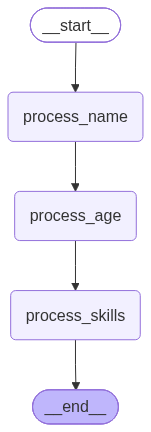

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))